In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def RK4(g,x0,t):
    h = t[1]-t[0]
    sol = np.zeros( (len(x0),len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        k1 = g(sol[:,i],t[i])
        k2 = g(sol[:,i]+0.5*k1*h,t[i]+0.5*h)
        k3 = g(sol[:,i]+0.5*k2*h,t[i]+0.5*h)
        k4 = g(sol[:,i]+k3*h,t[i]+h)
        sol[:,i+1] = sol[:,i] + h*(k1 + 2*k2 + 2*k3 + k4)/6
    return sol

In [3]:
def Sist_solar(x_v,t):
    # x_v = (x,y,vx,vy)
    dx , dy = x_v[2] , x_v[3]
    r32 = (x_v[0]**2 + x_v[1]**2 )**1.5
    dvx , dvy = -x_v[0]/r32 , -x_v[1]/r32
    return np.array([dx,dy,dvx,dvy])

In [4]:
ci = np.array([ 1 , 0 , 0 , 1 ])
t = np.arange(0,50*np.pi,0.005)
x_v = RK4(Sist_solar,ci,t)

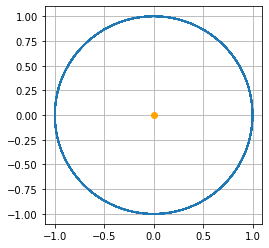

In [5]:
plt.plot(x_v[0,:],x_v[1,:])
plt.gca().set_aspect('equal')
plt.plot([0],[0],'o',color='orange')
plt.grid()
plt.show()

t_final =  314.16
t_final =  314.16
Diferencia 1.0413246931406661e-09


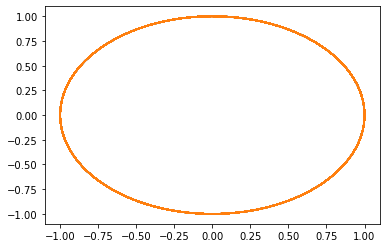

In [6]:
ci = np.array([ 1 , 0 , 0 , 1 ])
delta = 0.005
t = np.arange(0,100*np.pi+delta,delta)
print('t_final = ',t[-1])
x_v1 = RK4(Sist_solar,ci,t)
delta = 0.01
t = np.arange(0,100*np.pi+delta,0.01)
print('t_final = ',t[-1])
x_v2 = RK4(Sist_solar,ci,t)
print('Diferencia', abs(x_v1[0,-1]-x_v2[0,-1] ))
plt.plot(x_v1[0,:],x_v1[1,:])
plt.plot(x_v2[0,:],x_v2[1,:])
plt.show()

In [7]:
delta = 0.1
t = np.arange(0,100+delta,delta)
x_v = RK4(Sist_solar,ci,t)
pto_ref = x_v[0,-1]
print(delta,t[-1],pto_ref)
contador = 8
deltas = np.zeros(contador)
errores = np.zeros(contador)
for i in range(contador):
    delta = 0.5*delta
    t = np.arange(0,100+delta,delta)
    x_v = RK4(Sist_solar,ci,t)
    deltas[i] = delta
    errores[i] = abs(pto_ref-x_v[0,-1])
    pto_ref = x_v[0,-1]
    print(delta,t[-1],pto_ref)

0.1 100.0 0.8634653446600007
0.05 100.0 0.8623583771914075
0.025 100.0 0.8623203345798786
0.0125 100.0 0.8623189322249952
0.00625 100.0 0.8623188750507323
0.003125 100.0 0.8623188724287019
0.0015625 100.0 0.8623188722940576
0.00078125 100.0 0.8623188722851074
0.000390625 100.0 0.8623188722857947


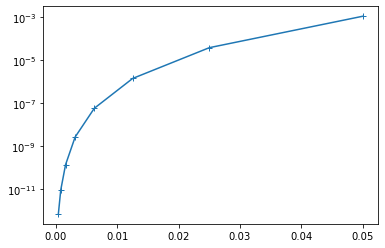

In [8]:
plt.semilogy(deltas,errores,'+-')
plt.show()

In [9]:
delta = 0.1
t = np.arange(0,100+delta,delta)
x_v = RK4(Sist_solar,ci,t)
pto_ref = x_v[0,-1]
print(delta,t[-1],pto_ref)
contador = 4
deltas = np.zeros(contador)
errores = np.zeros(contador)
for i in range(contador):
    delta = delta*0.1
    t = np.arange(0,100+delta,delta)
    x_v = RK4(Sist_solar,ci,t)
    deltas[i] = delta
    errores[i] = abs(pto_ref-x_v[0,-1])
    pto_ref = x_v[0,-1]
    print(delta,t[-1],pto_ref)

0.1 100.0 0.8634653446600007
0.010000000000000002 100.00000000000001 0.8623188942615521
0.0010000000000000002 100.00000000000003 0.8623188722880867
0.00010000000000000003 100.00000000000003 0.8623188722848875
1.0000000000000004e-05 100.00000000000004 0.8623188723028362


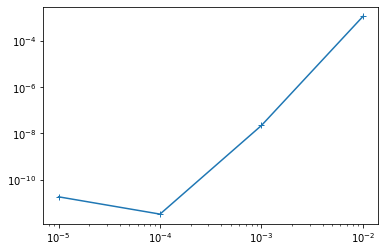

In [11]:
plt.loglog(deltas,errores,'+-')
plt.show()

In [25]:
delta = 0.1
#
ci = np.array([ 1 , 0 , 0 , 1 ])
t = np.arange(0,100+delta,delta)
x_v = RK4(Sist_solar,ci,t)
print(ci[0],ci[1])
print(t[0],t[-1])
print(x_v[0,-1],x_v[1,-1])
ci = x_v[:,-1]
t = t[::-1]
x_v = RK4(Sist_solar,ci,t)
print(ci[0],ci[1])
print(t[0],t[-1])
print(x_v[0,-1],x_v[1,-1])

1 0
0.0 100.0
0.8634653446600007 -0.5043523431273509
0.8634653446600007 -0.5043523431273509
100.0 0.0
0.9999353865941184 -0.0041760714675427996


In [33]:
delta = 0.1
contador = 5
deltas = np.zeros(contador)
errores = np.zeros(contador)
for i in range(contador):
    deltas[i] = delta
    ci_ref = np.array([ 1 , 0 , 0 , 1 ])
    #print(ci_ref)
    t = np.arange(0,100+delta,delta)
    x_v = RK4(Sist_solar,ci_ref,t)
    ci = x_v[:,-1]
    t = t[::-1]
    x_v = RK4(Sist_solar,ci,t)
    #print(x_v[:,-1])
    errores[i] = abs(ci_ref[0]-x_v[0,-1])
    print(delta,errores[i])
    delta = delta*0.1

0.1 6.461340588159725e-05
0.010000000000000002 5.576705763843393e-10
0.0010000000000000002 2.2870594307278225e-14
0.00010000000000000003 6.8833827526759706e-15
1.0000000000000004e-05 1.0578204978628492e-12


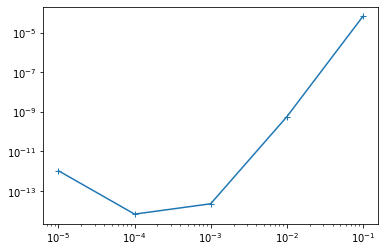

In [34]:
plt.loglog(deltas,errores,'+-')
plt.show()

In [35]:
import scipy.integrate as si

In [47]:
def Sist_solar_mod(t,x_v):
    # x_v = ( x,y,vx,vy )
    dx = x_v[2]
    dy = x_v[3]
    r32 = (x_v[0]**2 + x_v[1]**2 )**1.5
    dvx , dvy = -x_v[0]/r32 , -x_v[1]/r32
    return np.array([dx,dy,dvx,dvy])

In [53]:
ci = [ 1 , 0 , 0 , 1 ]
t = (0,50*np.pi)
x_v = si.solve_ivp(Sist_solar_mod,t,ci)
x_v

  message: 'Required step size is less than spacing between numbers.'
     nfev: 11960
     njev: 0
      nlu: 0
      sol: None
   status: -1
  success: False
        t: array([0.00000000e+00, 9.99000999e-04, 1.09890110e-02, ...,
       8.04179148e+01, 8.04179148e+01, 8.04179148e+01])
 t_events: None
        y: array([[ 1.00000000e+00,  9.99999501e-01,  9.99939621e-01, ...,
        -2.62755797e-09, -9.18690575e-10,  1.67995795e-09],
       [ 0.00000000e+00,  9.99000833e-04,  1.09887898e-02, ...,
        -4.75093405e-10, -2.48831885e-09, -1.99640728e-09],
       [ 0.00000000e+00, -9.99000833e-04, -1.09887898e-02, ...,
         3.60148260e+03,  1.82889008e+04,  1.46403684e+04],
       [ 1.00000000e+00,  9.99999501e-01,  9.99939621e-01, ...,
        -1.90802475e+04, -6.46822818e+03,  1.29651835e+04]])
 y_events: None

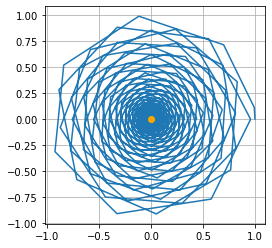

In [52]:
plt.plot(x_v.y[0],x_v.y[1])
plt.gca().set_aspect('equal')
plt.plot([0],[0],'o',color='orange')
plt.grid()
plt.show()